## 05 Plotter

This notebook explains each function in the plotter module. These functions produce VAPOR  output images.

In [3]:
# import cv2
import cv2 as cv
# import modules
import convenience as con
import support as sup
import core as cor
import numpy as np
import plotter as pltr
from astropy.wcs import WCS
import matplotlib.pyplot as plt

# Display the saved image in the notebook
from IPython.display import Image, display
from astropy.constants import au

In [2]:

# Point to test data, and create list of total brightness and polarized brightness image pair
tb_base_fits="/Volumes/Helios/PUNCH/vapor_data/outdata/20130226_100815_n4c2A_B_base.fts"
pb_base_fits="/Volumes/Helios/PUNCH/vapor_data/outdata/20130226_100815_n4c2A_pB_base.fts"

tb_fits="/Volumes/Helios/PUNCH/vapor_data/outdata/20130226_140815_n4c2A_B.fts"
pb_fits="/Volumes/Helios/PUNCH/vapor_data/outdata/20130226_140815_n4c2A_pB.fts"
# #
# tb_base_fits="/Volumes/Helios/PUNCH/vapor_data/outdata/20130226_100815_n4c2B_B_base.fts"
# pb_base_fits="/Volumes/Helios/PUNCH/vapor_data/outdata/20130226_100815_n4c2B_pB_base.fts"
#
# tb_fits="/Volumes/Helios/PUNCH/vapor_data/outdata/20130226_120915_n4c2B_B.fts"
# pb_fits="/Volumes/Helios/PUNCH/vapor_data/outdata/20130226_120915_n4c2B_pB.fts"

### Function create_figure
This function accepts a list of total and polarized brightness FITS, and optionally matching base images and generates a distance map as a .png file

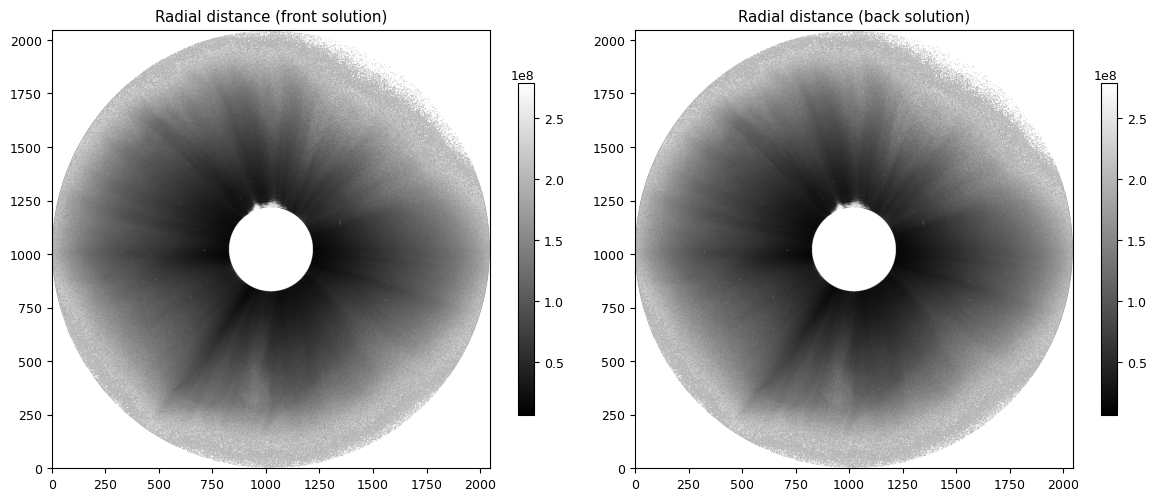

In [21]:
# tb_fits = "./test_data/stereo/20121109_030915_B.fts"
# pb_fits = "./test_data/stereo/20121109_030915_pB.fts"

# Front and back heliocentric radial distance
r_front = cor.radial_position_ps(tb_fits, pb_fits, return_key="r_front")
r_back  = cor.radial_position_ps(tb_fits, pb_fits, return_key="r_back")

sol_radii=695700 #km"
r_front=con.clean_distance(r_front, 200.0*sol_radii)
r_back=con.clean_distance(r_back, 200.0*sol_radii)


# Visual comparison
con.show_2_images(
    r_front, r_back,
    title1="Radial distance (front solution)",
    title2="Radial distance (back solution)"
)

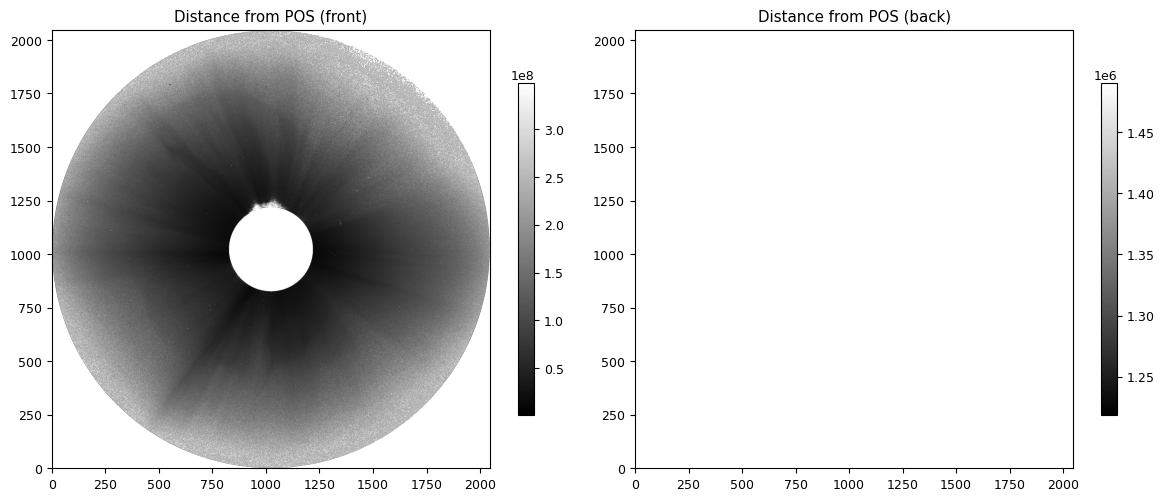

In [18]:
# Inspect LOS geometry quantities
# Useful for sanity checks and understanding where features sit relative to the Thomson Surface.

# LOS distance from observer
l_front = cor.radial_position_ps(tb_fits, pb_fits, return_key="l_front")
l_back  = cor.radial_position_ps(tb_fits, pb_fits, return_key="l_back")

# Distance from plane of sky
x_front = cor.radial_position_ps(tb_fits, pb_fits, return_key="x_front")
x_back  = cor.radial_position_ps(tb_fits, pb_fits, return_key="x_back")

sol_radii=695700 #km"
x_front=con.clean_distance(x_front, 250.0*sol_radii)
x_back=con.clean_distance(x_back, 250.0*sol_radii)

con.show_2_images(
    x_front, x_back,
    title1="Distance from POS (front)",
    title2="Distance from POS (back)"
)

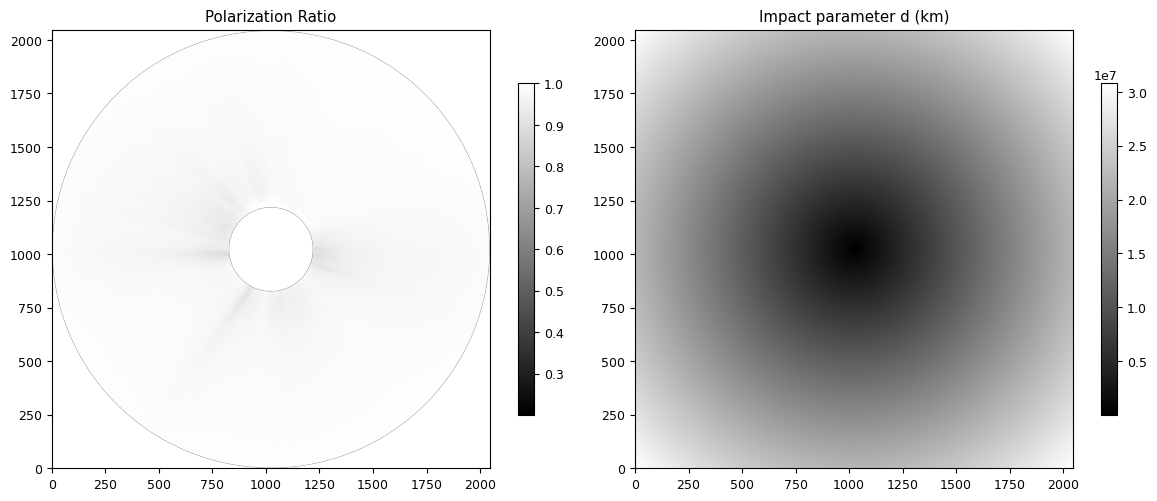

In [5]:
PR = cor.radial_position_ps(tb_fits, pb_fits, return_key="PR")
epsilon = cor.radial_position_ps(tb_fits, pb_fits, return_key="epsilon_map")
d_map = cor.radial_position_ps(tb_fits, pb_fits, return_key="d_map")

con.show_2_images(
    PR, d_map,
    title1="Polarization Ratio",
    title2="Impact parameter d (km)"
)

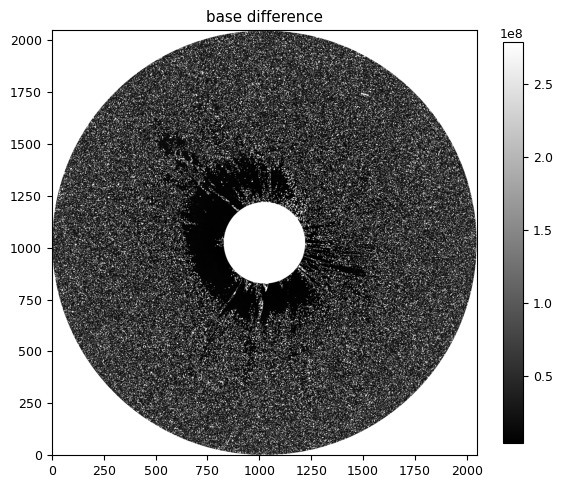

In [6]:
r_front_bgsub = cor.radial_position_ps(
    tb_fits,
    pb_fits,
    return_key="r_front",
    subtract_base_image=True,
    base_tb_path=tb_base_fits,
    base_pb_path=pb_base_fits,
)

sol_radii=695700 #km"
r_front_bgsub=con.clean_distance(r_front_bgsub, 200.0*sol_radii)

con.show_1_image(r_front_bgsub,  title1="base difference")


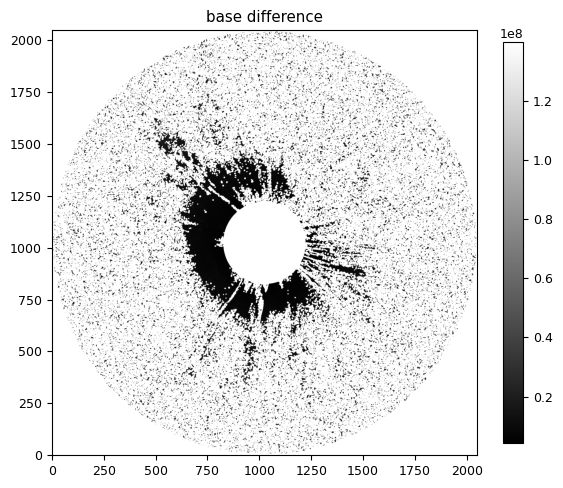

In [7]:
from scipy.ndimage import gaussian_filter

# Apply median filter
median_filtered_image = gaussian_filter(r_front_bgsub, sigma=0.6)

con.show_1_image(median_filtered_image,  title1="base difference")

In [8]:
test_r_front = cor.radial_position_ps(tb_fits, pb_fits, return_key="r_front")
base_r_front = cor.radial_position_ps(tb_base_fits, pb_base_fits, return_key="r_front")

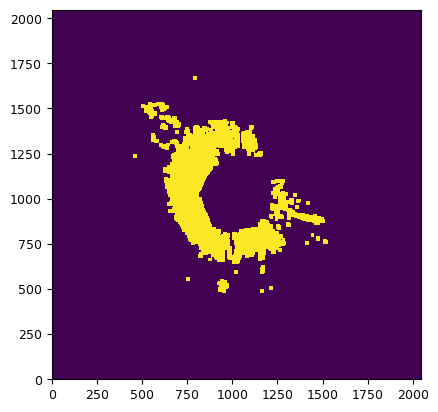

In [9]:
mask = median_filtered_image < 2e7
kernel = np.ones((5,5),np.uint8)
test=mask.astype(np.uint8)
test = cv.erode(test,kernel,iterations = 2)

test = cv.dilate(test,kernel,iterations = 2)
for i in range(3):
    test = cv.dilate(test,kernel,iterations = 1)
    test = cv.morphologyEx(test,cv.MORPH_CLOSE,kernel)

plt.imshow(test, origin="lower", interpolation="None")

In [155]:
from scipy.ndimage import label

In [157]:
labeltest, maxcnt = label(test)

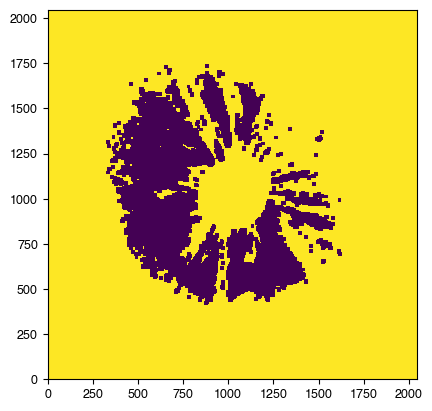

In [164]:
plt.imshow(labeltest==0, origin="lower", interpolation="None")

In [103]:
imgtest = (r_front_bgsub)/6.95e5
# imgtest = cv.GaussianBlur(imgtest, (5,5), 0)


kernel = np.ones((5,5),np.uint8)
erosion = cv.erode(imgtest,kernel,iterations = 1) # prefereably in binary
img_morph = cv.dilate(imgtest,kernel,iterations = 1)

In [131]:
from scipy.ndimage import generic_filter
import numpy as np

# Example: Apply 3x3 standard deviation filter
# filtered_image = generic_filter(imgtest, np.std, size=3)
filtered_image_morph = generic_filter(img_morph, np.std, size=3)
# Apply filter
# stdev_image = window_stdev(imgtest, window_size=3)


/opt/anaconda3/envs/punchbowl/lib/python3.12/site-packages/numpy/_core/_methods.py:171: RuntimeWarning: overflow encountered in reduce
  arrmean = umr_sum(arr, axis, dtype, keepdims=True, where=where)


/opt/anaconda3/envs/punchbowl/lib/python3.12/site-packages/matplotlib/colors.py:778: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


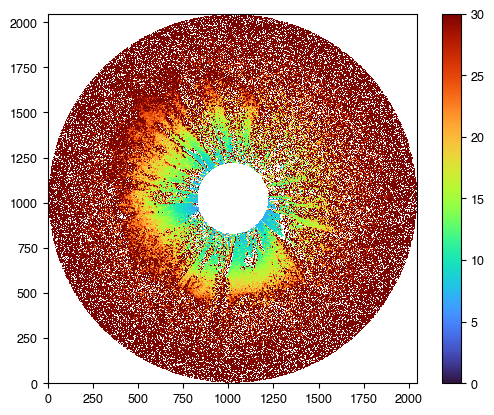

In [130]:
fig, ax = plt.subplots()
im = ax.imshow(img_morph, cmap="turbo", origin="lower", vmin=0, vmax=30, interpolation="None")
cb = fig.colorbar(im, ax=ax)
plt.show()

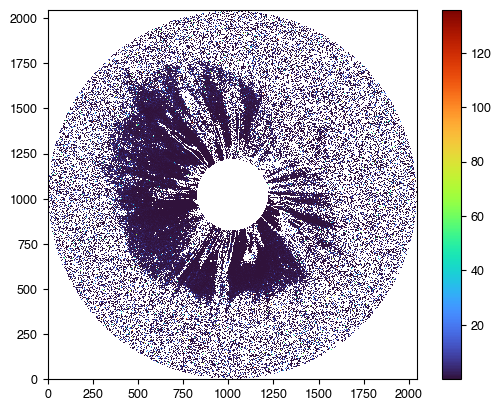

In [127]:
fig, ax = plt.subplots()
im = ax.imshow(filtered_image, cmap="turbo", origin="lower", interpolation="None")#, vmin=0, vmax=30, interpolation="None")
cb = fig.colorbar(im, ax=ax)
plt.show()

(-20.0, 100.0)

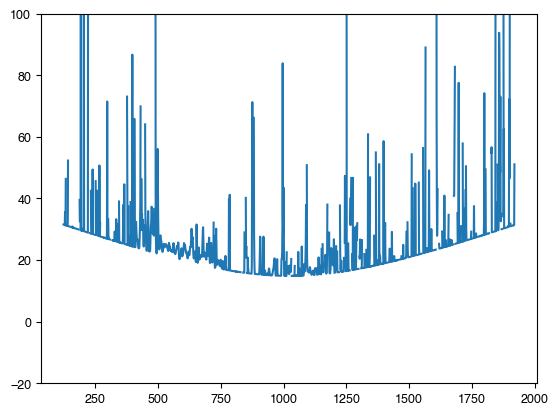

In [108]:
# diff_test = gaussian_filter(imgtest[1500,:], sigma=1.0)
fig, ax = plt.subplots()
im = ax.plot(imgtest[1500,:])
ax.set_ylim(-20, 100)

In [115]:
print(imgtest[1500,500:1000])

[34.06697301 28.57668464 26.28550681 24.65767325 23.64879555 23.45014763
 24.06550993 25.6197076  27.55448835 28.02497437 27.04499059 26.55201198
 26.37272865 25.8747026  24.90118839 24.05044989 23.19676999 22.65579609
 22.74770644 23.08005978 23.72330312 24.52679654 25.20999435 25.28241613
 24.68026987 24.22598449 24.15623581 24.28641687 24.51847833 24.75330302
 25.00861514 25.19990662 25.11144156 24.89949906 24.64949556 24.379873
 24.1137328  23.84585028 23.53848481 23.13287095 22.94119987 23.37170573
 24.55332672 25.58998665 25.25867365 24.6362121  24.48847551 24.41262126
 23.97486108 23.2923414  22.93446588 23.01578974 23.15468902 23.07289172
 22.82625868 22.67237511 22.61953565 22.60665768 22.79758553 23.44933546
 24.67454912 25.50054253 25.04016289 23.93334367 22.95463405 22.43117094
 22.17950705 22.0540908  21.95465129 22.00836208 22.4859998  22.92245606
 23.2017482  23.59425172 24.1438661  24.62696872 24.37019143 23.999821
 24.21466829 25.05636009 25.68924933 24.76703644 22.922

In [ ]:
fig, ax = plt.subplots()
im = ax.hist(diff_test, bins=100, range=(0, 50),cumulative=True, density=True, histtype='stepfilled')


In [3]:
radmap, morph_mask, minxy, maxxy = pltr.create_triple_stereo_plot(
        file_list=[tb_fits, pb_fits],
        data_type="stereo",
        output_method="ps",
        solution="plus",        # back solution
        quantity="los",          # LOS distance
        subtract_base_image=True,
        base_file_list=[tb_base_fits, pb_base_fits],
        # image_name="./output/LOS_STA_solution.png",
        image_name=tb_fits[:-6],
        plot_min=1,
        plot_max=30,
        verbose=True,
        color_map="turbo",
        apply_morph=True)

x max: He:li:os 30.570508630071544
y max: He:li:os 30.497357810918515


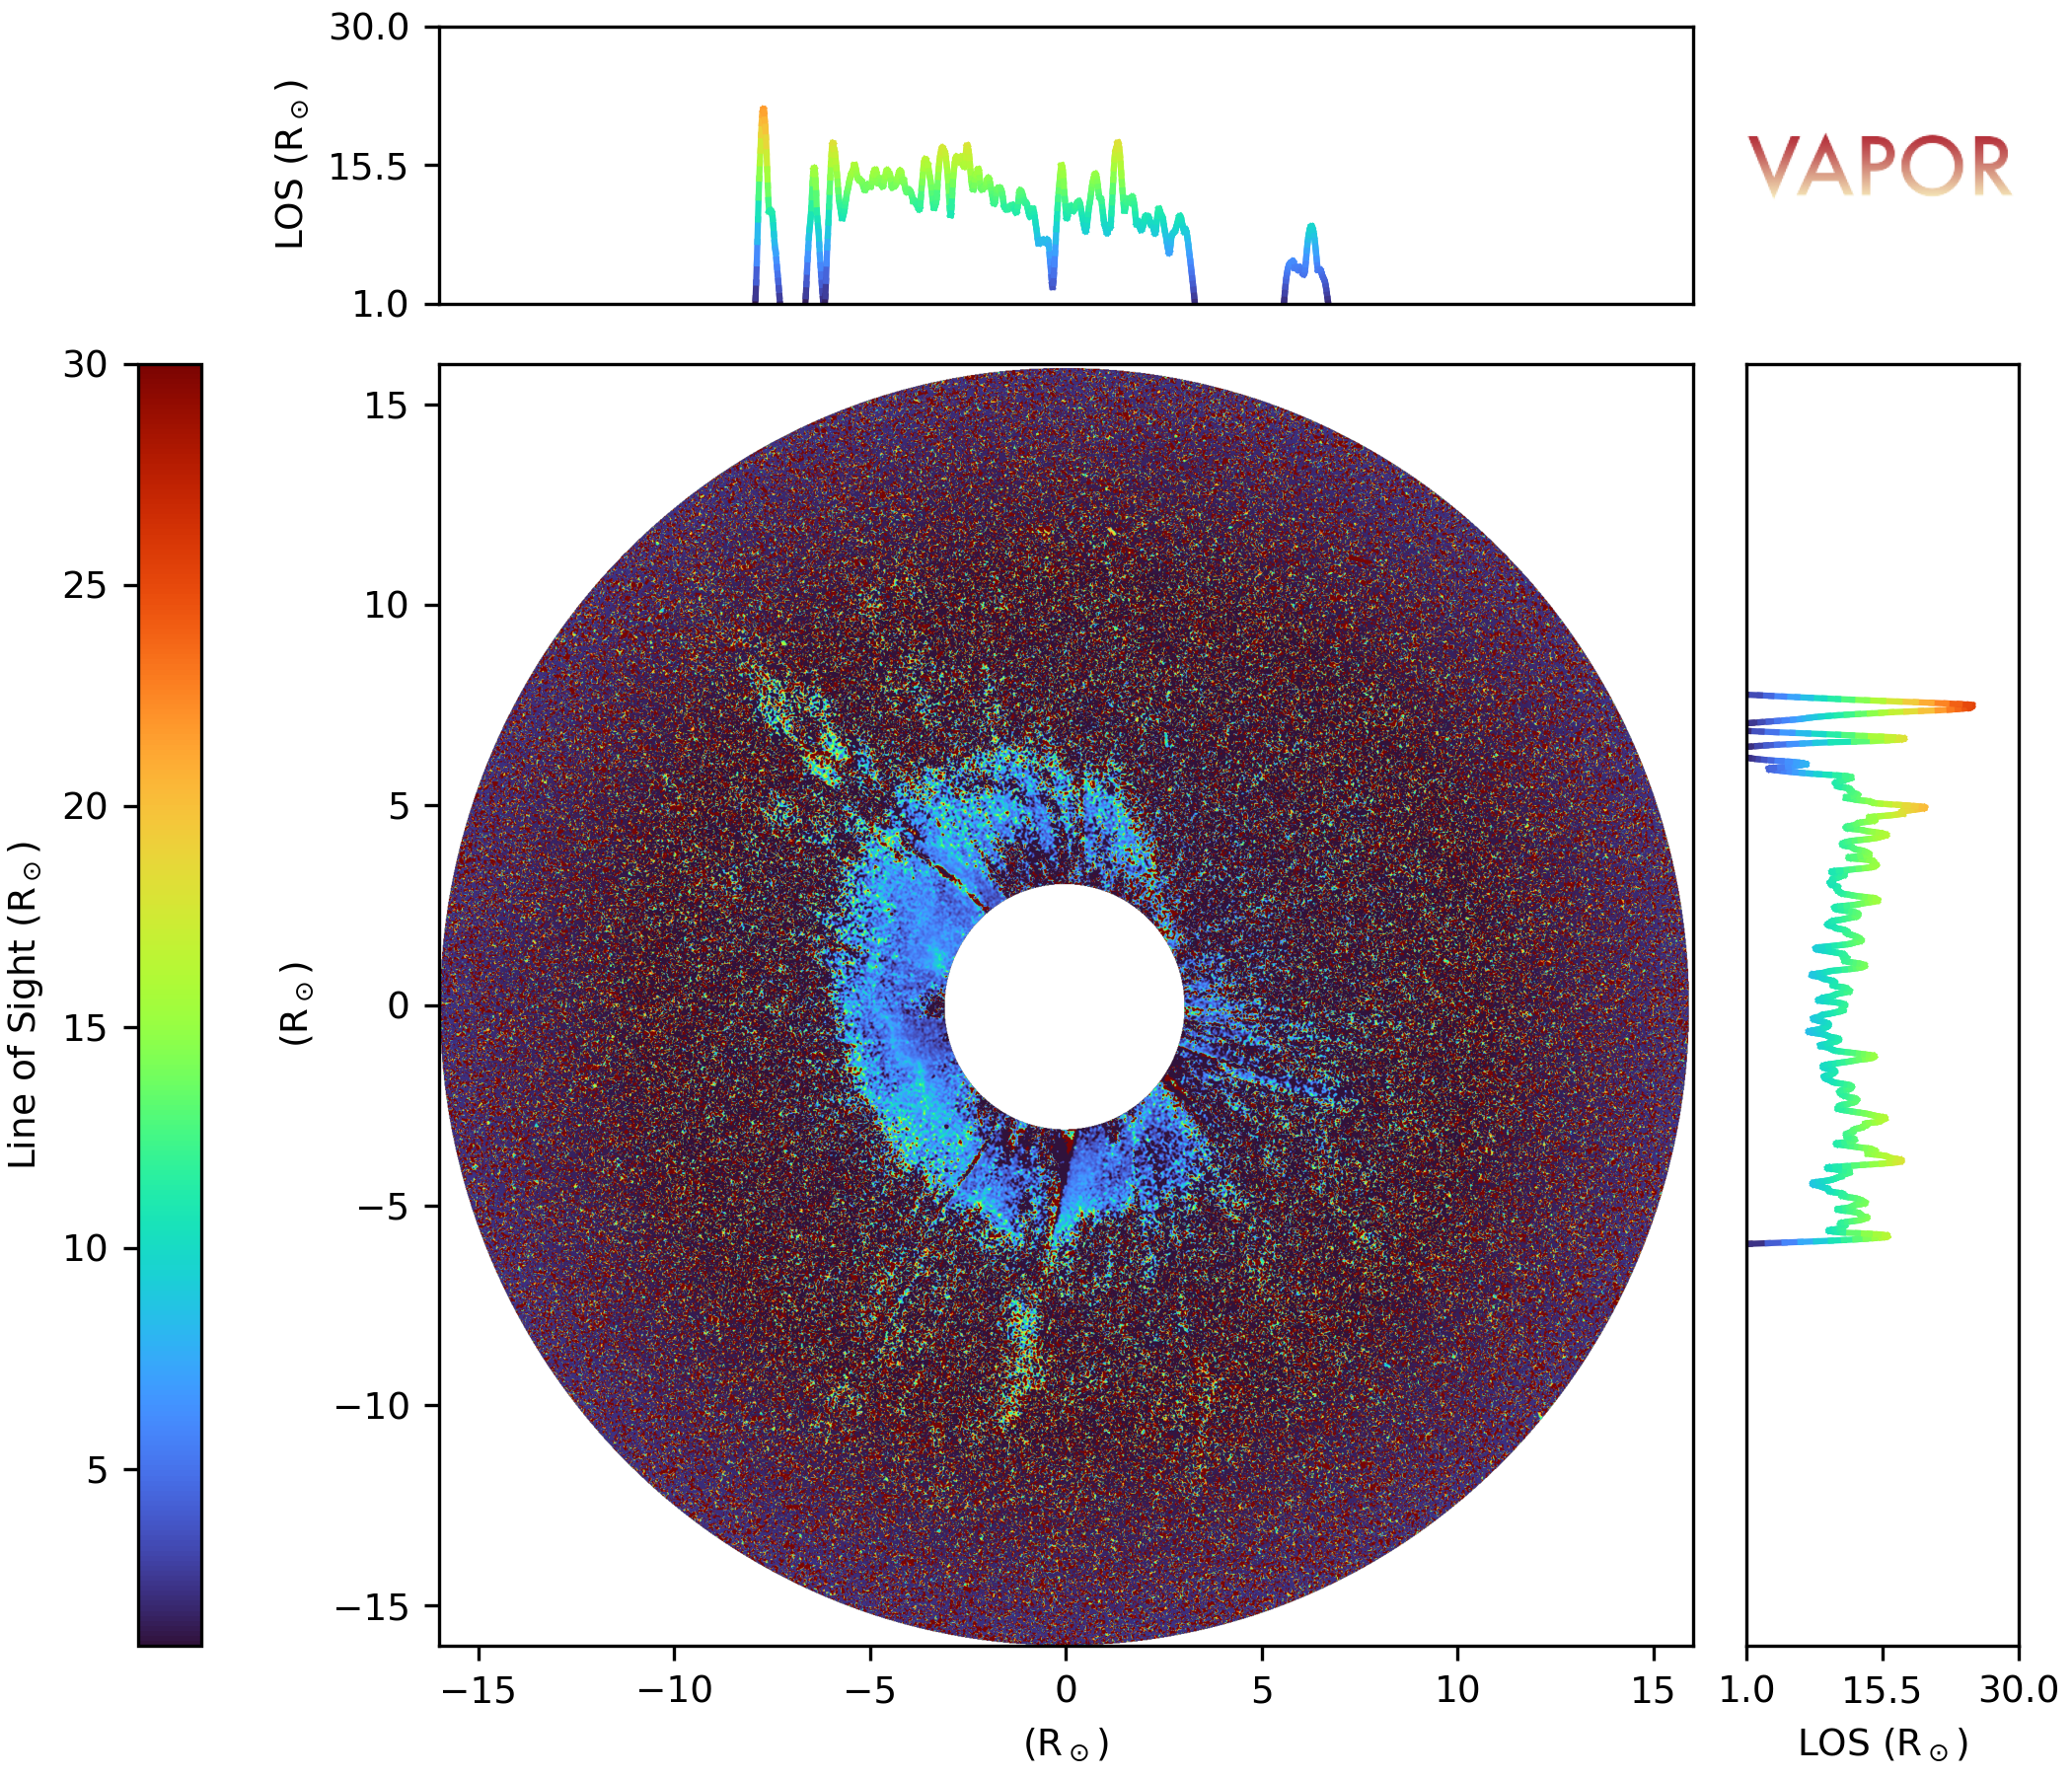

In [11]:
display(Image(filename="./output/LOS_STA_solution.png"))

- apply morph close before passing main image to right and top panel in plotter.py
-

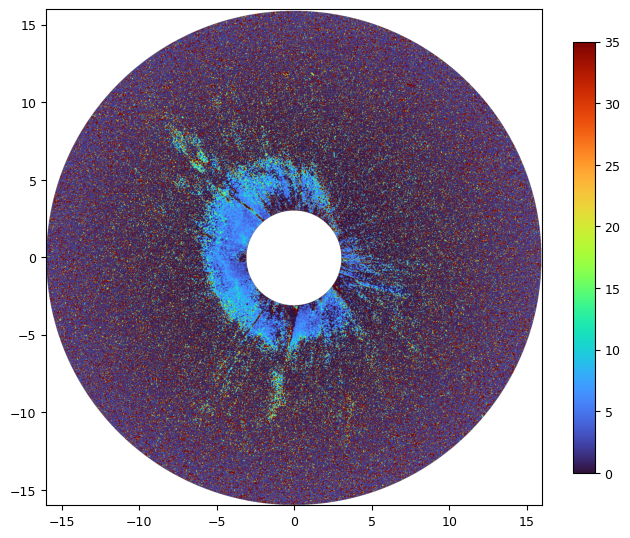

In [12]:
fig, ax = plt.subplots(figsize=(8,8))
im = ax.imshow(radmap, origin="lower",
               cmap="turbo", extent=[minxy, maxxy, minxy, maxxy],
               vmax=35,
               vmin=0)
cb = fig.colorbar(im, ax=ax, shrink=0.7)
plt.show()

In [18]:
from astropy.io import fits
import matplotlib.pyplot as plt
import astropy.units as u
import os
from sunpy.sun import constants
from matplotlib.patches import Circle
from scipy.ndimage import gaussian_filter

In [50]:
# Point to test data, and create list of total brightness and polarized brightness image pair
# tb_base_fits="/Volumes/Helios/PUNCH/vapor_data/outdata/20130226_100815_n4c2A_B_base.fts"
# pb_base_fits="/Volumes/Helios/PUNCH/vapor_data/outdata/20130226_100815_n4c2A_pB_base.fts"
#
# tb_fits="/Volumes/Helios/PUNCH/vapor_data/outdata/20130226_140815_n4c2A_B.fts"
# pb_fits="/Volumes/Helios/PUNCH/vapor_data/outdata/20130226_140815_n4c2A_pB.fts"
# #
tb_base_fits="/Volumes/Helios/PUNCH/vapor_data/outdata/20130226_100815_n4c2B_B_base.fts"
pb_base_fits="/Volumes/Helios/PUNCH/vapor_data/outdata/20130226_100815_n4c2B_pB_base.fts"

tb_fits="/Volumes/Helios/PUNCH/vapor_data/outdata/20130226_130845_n4c2B_B.fts"
pb_fits="/Volumes/Helios/PUNCH/vapor_data/outdata/20130226_130845_n4c2B_pB.fts"

In [51]:
basedata = fits.open(tb_base_fits)
cmedata = fits.open(tb_fits)

In [52]:
fimg = cmedata[0].data
center_x = cmedata[0].header['CRPIX1']
center_y = cmedata[0].header['CRPIX2']
R_sun = 960. / cmedata[0].header['CDELT1']

R_i = 3.15

# Calibrate to solar radius
x = np.empty(fimg.shape[0])
y = np.empty(fimg.shape[1])
for i in range(len(x)):
    x[i] = (i - center_x) / R_sun
    y[i] = (i - center_y) / R_sun

n, m = fimg.shape
rr = np.max(y) * R_sun
xx, yy = np.ogrid[0:n, 0:m]
msk = np.ones(fimg.shape)  # the final mask array
mask = (xx - center_x) ** 2 + (yy - center_y) ** 2 < (R_i * R_sun) ** 2
msk[mask] = 0
mask = (xx - center_x) ** 2 + (yy - center_y) ** 2 > rr ** 2
msk[mask] = 0

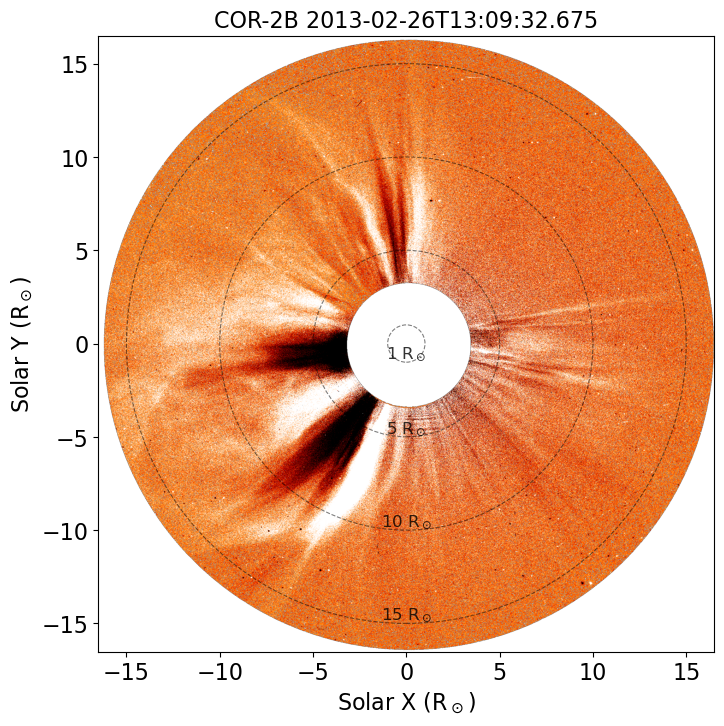

In [53]:
img = (cmedata[0].data - basedata[0].data)
vmin,vmax = np.nanpercentile(img,[1,95])
cmap="gist_heat"
fsize=16
# radii = np.arange(1, 21, 4)
radii = [1, 5, 10, 15]
w = WCS(cmedata[0].header)

rsun_ref = constants.radius     # meters
rsun_arc = cmedata[0].header["RSUN"]     # arcsec
cdelt = cmedata[0].header["CDELT1"]    # arcsec/pix

km_per_pix = cdelt * rsun_ref / rsun_arc / 1000.0
rsun_per_pix = km_per_pix / (rsun_ref/1000.0)

ny, nx = img.shape
x = (np.arange(nx) - (nx-1)/2) * rsun_per_pix
y = (np.arange(ny) - (ny-1)/2) * rsun_per_pix

fig, ax = plt.subplots(figsize=(8,8))
img2 = np.ma.masked_where((img*msk) == 0, img*msk)
ax.set_facecolor("white")

im = ax.imshow(img2, origin="lower",
               vmin=vmin, vmax=vmax, cmap=cmap,
               extent=[x.min(), x.max(), y.min(), y.max()])
ax.set_xlabel("Solar X (R$_\\odot$)", fontsize=fsize)
ax.set_ylabel("Solar Y (R$_\\odot$)", fontsize=fsize)
ax.tick_params(axis="both", labelsize=fsize)
ax.set_title("COR-2B "+cmedata[0].header["DATE-OBS"], fontsize=fsize)
# plt.colorbar(im, ax=ax)

for r in radii:
    ax.add_patch(Circle((0.0, 0.0), r,
               fill=False, edgecolor="black",
               linewidth=0.8, linestyle="--",
               alpha=0.5, zorder=5))
    ax.text(0, -r, f"{r} R$_\\odot$", color="black", fontsize=12,
            ha="center", va="bottom", alpha=0.8)

ax.set_aspect("equal")

plt.show()

In [54]:
fig.savefig(os.path.join("/Volumes/Helios/PUNCH/vapor_data/someres/", f"{os.path.splitext(os.path.basename(tb_fits))[0]}.png"), dpi=300)